# TAHAP 5 — Evaluasi Model pada Test Set

Evaluasi final model hybrid pada **test set** (data yang belum pernah dilihat saat training maupun tuning).

**Input:**
- `data/splits/X_test.csv`, `y_test.csv`
- `models/isolation_forest.pkl`, `best_supervised.pkl`
- `models/model_metadata.json`

**Metrics:** Accuracy, Precision, Recall, F1-Score (per kelas & macro), Confusion Matrix

## Import & Load

In [25]:
import os
import json
import warnings

import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    classification_report, confusion_matrix, accuracy_score,
    f1_score, precision_score, recall_score
)

warnings.filterwarnings('ignore')
sns.set_style("whitegrid")

# Paths
SPLITS_DIR  = os.path.join("..", "data", "splits")
MODELS_DIR  = os.path.join("..", "models")

# Load test data
X_test = pd.read_csv(os.path.join(SPLITS_DIR, "X_test.csv"))
y_test = pd.read_csv(os.path.join(SPLITS_DIR, "y_test.csv"))["severity_encoded"]

# Load models
if_pipe    = joblib.load(os.path.join(MODELS_DIR, "isolation_forest.pkl"))
best_model = joblib.load(os.path.join(MODELS_DIR, "best_supervised.pkl"))

# Load metadata
with open(os.path.join(MODELS_DIR, "model_metadata.json")) as f:
    meta = json.load(f)

SEVERITY_LABELS = meta["class_labels"]
MODEL_NAME = meta["model_name"]

print(f"[OK] Data & model loaded")
print(f"     Model: {MODEL_NAME}")
print(f"     Test set: {X_test.shape[0]:,} baris")

[OK] Data & model loaded
     Model: RandomForest
     Test set: 435 baris


## Prediksi pada Test Set

In [26]:
print("[1/4] Menghitung prediksi pada test set...")

# Tambahkan IF anomaly score ke test features
if_score_test = -if_pipe.decision_function(X_test)
X_test_aug = X_test.copy()
X_test_aug["if_anomaly_score"] = if_score_test

# Prediksi
y_pred = best_model.predict(X_test_aug)

# Probabilities (untuk analisis tambahan)
y_proba = best_model.predict_proba(X_test_aug)

print(f"      Prediksi selesai: {len(y_pred):,} transaksi")

[1/4] Menghitung prediksi pada test set...
      Prediksi selesai: 435 transaksi


## Classification Report

In [27]:
print("[2/4] Classification Report (Test Set)")
print(f"      Model: {MODEL_NAME}\n")

print(classification_report(y_test, y_pred,
                            target_names=SEVERITY_LABELS,
                            digits=3, zero_division=0))

# Metrics ringkasan
acc    = accuracy_score(y_test, y_pred)
f1_mac = f1_score(y_test, y_pred, average="macro")
f1_wt  = f1_score(y_test, y_pred, average="weighted")

print(f"  Accuracy      : {acc:.4f}")
print(f"  F1-macro      : {f1_mac:.4f}")
print(f"  F1-weighted   : {f1_wt:.4f}")

[2/4] Classification Report (Test Set)
      Model: RandomForest

              precision    recall  f1-score   support

         LOW      0.997     0.989     0.993       375
      MEDIUM      1.000     1.000     1.000        27
        HIGH      0.810     0.944     0.872        18
    CRITICAL      1.000     1.000     1.000        15

    accuracy                          0.989       435
   macro avg      0.952     0.983     0.966       435
weighted avg      0.990     0.989     0.989       435

  Accuracy      : 0.9885
  F1-macro      : 0.9663
  F1-weighted   : 0.9889


## Confusion Matrix

[3/4] Confusion Matrix


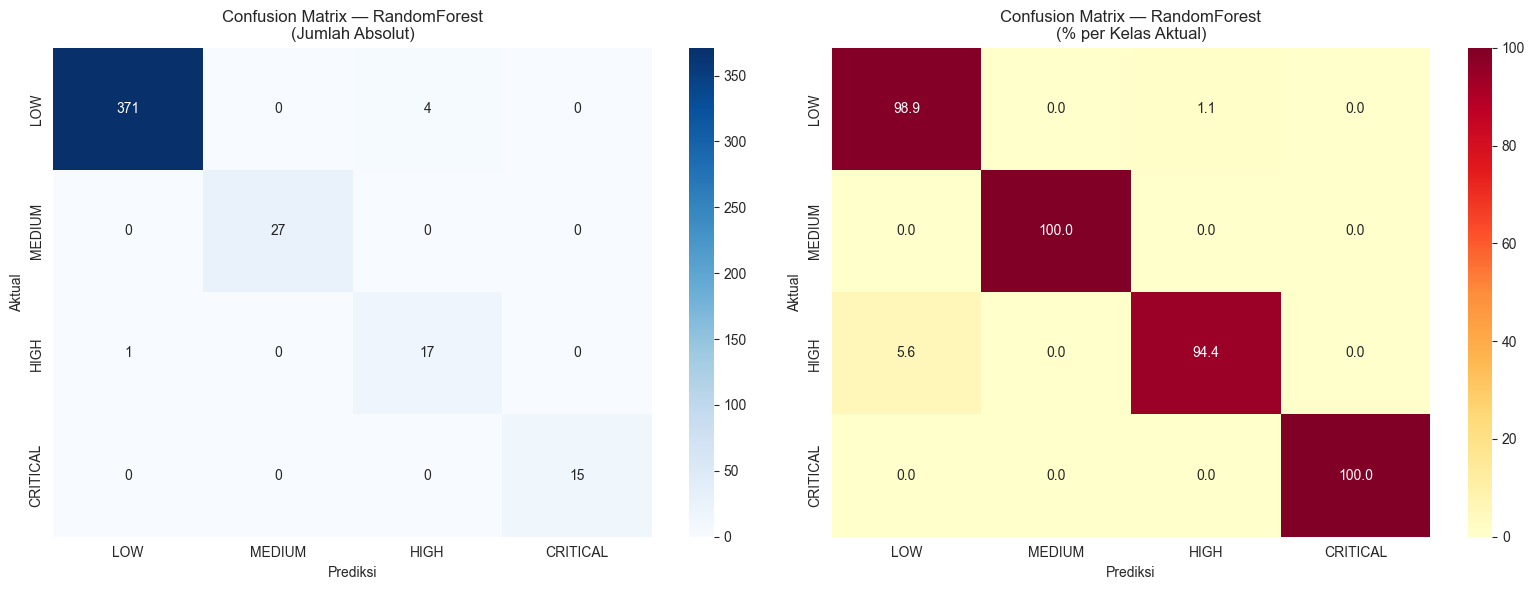

In [28]:
print("[3/4] Confusion Matrix")

cm = confusion_matrix(y_test, y_pred)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Confusion matrix (jumlah absolut)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=SEVERITY_LABELS,
            yticklabels=SEVERITY_LABELS,
            ax=axes[0])
axes[0].set_title(f"Confusion Matrix — {MODEL_NAME}\n(Jumlah Absolut)")
axes[0].set_ylabel("Aktual")
axes[0].set_xlabel("Prediksi")

# Confusion matrix (persentase per baris)
cm_pct = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100
sns.heatmap(cm_pct, annot=True, fmt=".1f", cmap="YlOrRd",
            xticklabels=SEVERITY_LABELS,
            yticklabels=SEVERITY_LABELS,
            ax=axes[1])
axes[1].set_title(f"Confusion Matrix — {MODEL_NAME}\n(% per Kelas Aktual)")
axes[1].set_ylabel("Aktual")
axes[1].set_xlabel("Prediksi")

plt.tight_layout()
plt.show()

## Feature Importance & Distribusi Prediksi

[4/4] Feature Importance & Distribusi Prediksi


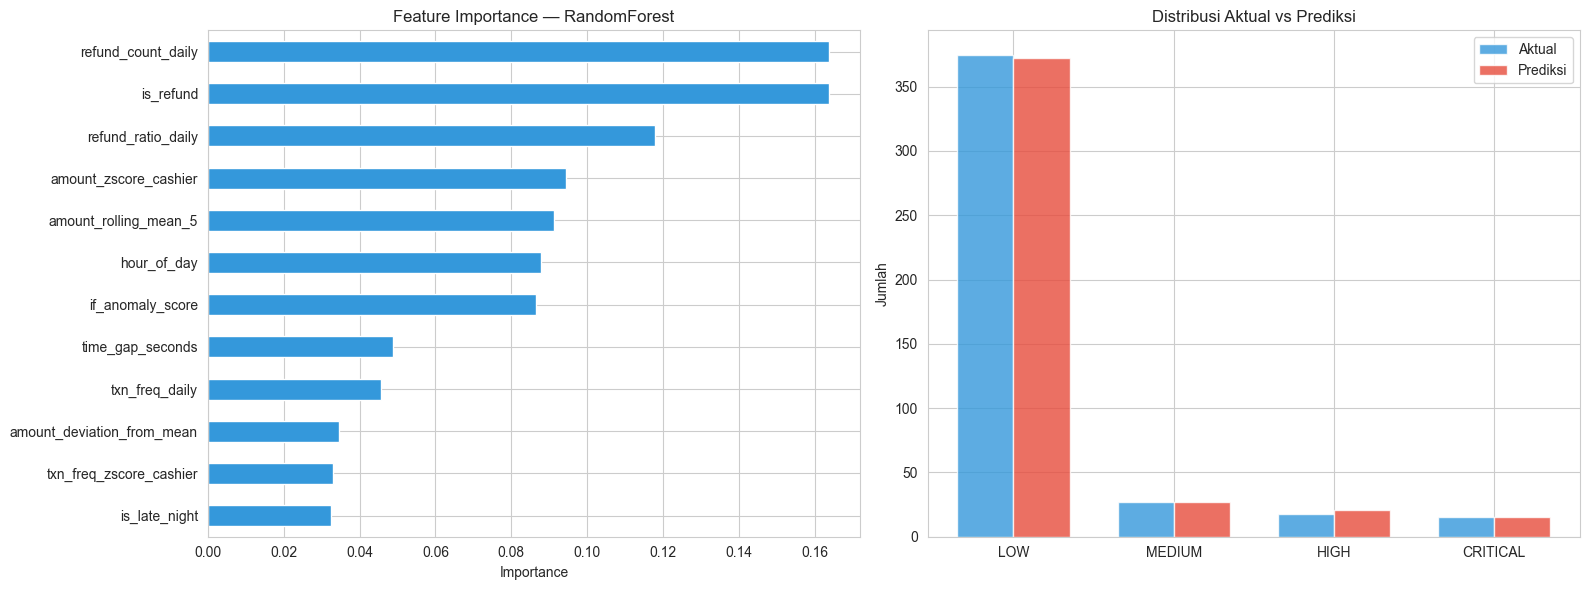

In [29]:
print("[4/4] Feature Importance & Distribusi Prediksi")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Feature importance
feat_imp = pd.Series(
    best_model.feature_importances_,
    index=X_test_aug.columns
).sort_values(ascending=True)

feat_imp.plot(kind="barh", ax=axes[0], color="#3498db", edgecolor="white")
axes[0].set_title(f"Feature Importance — {MODEL_NAME}")
axes[0].set_xlabel("Importance")

# Distribusi prediksi vs aktual
severity_colors = ["#2ecc71", "#f39c12", "#e67e22", "#e74c3c"]
x_pos = np.arange(len(SEVERITY_LABELS))
width = 0.35

aktual_counts = [int((y_test == i).sum()) for i in range(4)]
pred_counts   = [int((y_pred == i).sum()) for i in range(4)]

axes[1].bar(x_pos - width/2, aktual_counts, width, label="Aktual",
            color="#3498db", edgecolor="white", alpha=0.8)
axes[1].bar(x_pos + width/2, pred_counts, width, label="Prediksi",
            color="#e74c3c", edgecolor="white", alpha=0.8)
axes[1].set_xticks(x_pos)
axes[1].set_xticklabels(SEVERITY_LABELS)
axes[1].set_title("Distribusi Aktual vs Prediksi")
axes[1].set_ylabel("Jumlah")
axes[1].legend()

plt.tight_layout()
plt.show()

## Kesimpulan

In [30]:
print("KESIMPULAN EVALUASI")
print(f"\n  Model Hybrid: Isolation Forest + {MODEL_NAME}")
print(f"  Test Set: {len(y_test):,} transaksi")
print(f"\n  Performa:")
print(f"    Accuracy      : {acc:.4f} ({acc*100:.1f}%)")
print(f"    F1-macro      : {f1_mac:.4f}")
print(f"    F1-weighted   : {f1_wt:.4f}")

# Per-class summary
print(f"\n  Per-class Recall (kemampuan mendeteksi):")
for i, label in enumerate(SEVERITY_LABELS):
    mask = y_test == i
    if mask.sum() > 0:
        recall_i = (y_pred[mask] == i).sum() / mask.sum()
        print(f"    {label:10s}: {recall_i:.1%} ({(y_pred[mask] == i).sum()}/{mask.sum()})")

print(f"\n  Catatan:")
print(f"    - Data sintetis, kondisi terkontrol")
print(f"    - Precision/recall hanya berlaku untuk fraud buatan ini")
print(f"    - Validasi nyata butuh kasus fraud terkonfirmasi dari pemilik UMKM")
print(f"\nEvaluasi selesai! Opsional: lanjut ke Tahap 6 (Hyperparameter Tuning)")

KESIMPULAN EVALUASI

  Model Hybrid: Isolation Forest + RandomForest
  Test Set: 435 transaksi

  Performa:
    Accuracy      : 0.9885 (98.9%)
    F1-macro      : 0.9663
    F1-weighted   : 0.9889

  Per-class Recall (kemampuan mendeteksi):
    LOW       : 98.9% (371/375)
    MEDIUM    : 100.0% (27/27)
    HIGH      : 94.4% (17/18)
    CRITICAL  : 100.0% (15/15)

  Catatan:
    - Data sintetis, kondisi terkontrol
    - Precision/recall hanya berlaku untuk fraud buatan ini
    - Validasi nyata butuh kasus fraud terkonfirmasi dari pemilik UMKM

Evaluasi selesai! Opsional: lanjut ke Tahap 6 (Hyperparameter Tuning)
